# Start with the mean of target values as your first prediction.
That’s your baseline model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example data
X = np.array([1000, 1500, 2000, 2500, 3000])  # square footage
y = np.array([200, 250, 270, 300, 360])       # price in thousands

# Step 1: initial model (mean of y)
F0 = np.mean(y)
print("Initial prediction (F0):", F0)


Initial prediction (F0): 276.0


# Compute Residuals

Residuals = Actual − Predicted

These are the “mistakes” the model made.

In [2]:
residuals = y - F0
print("Residuals:", residuals)


Residuals: [-76. -26.  -6.  24.  84.]


*Small houses are Overpredicted → residual positive*

*Large houses are underpredicted → residual negative*

*That’s a pattern — so we train the next model to predict these residuals!*

**Train Weak Learner on Residuals**

We’ll train a small decision tree to predict the residuals from X.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Train weak learner on residuals
tree1 = DecisionTreeRegressor(max_depth=2)
tree1.fit(X.reshape(-1, 1), residuals)
 #(n_samples,n_features)

# The weak learner predicts residuals
pred_residuals = tree1.predict(X.reshape(-1, 1))
print("Predicted residuals by tree:", pred_residuals)


Predicted residuals by tree: [-76. -16. -16.  24.  84.]


# Update Model

Now we add this weak learner’s predictions (scaled by learning rate α) to the previous model’s predictions.

In [ ]:
alpha = 0.1  # learning rate (Contribution of each model)
F1 = F0 + alpha * pred_residuals
print("Updated predictions after 1st iteration:", F1)


Updated predictions after 1st iteration: [275.99911617 275.99955761 276.00021286 276.00021286 276.00090049]


*Compute new residuals again (actual - new predictions), train another tree, and add it again.*

*Each new tree keeps “chasing” the remaining errors until performance stabilizes.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# --------------------------
# 1. DATA
# --------------------------
X = np.array([1000, 1500, 2000, 2500, 3000]).reshape(-1, 1)
y = np.array([200, 250, 270, 300, 360])  # in thousands



In [ ]:
# --------------------------
# 2. INITIALIZE MODEL
# --------------------------
F0 = np.mean(y)  # Start with mean of target
pred = np.full_like(y, F0, dtype=float)    #Creates an array of same shape as y, filled with F0

print(f"Initial prediction (F0): {F0:.2f}")

#pred = [276., 276., 276., 276., 276.]

Initial prediction (F0): 276.00


In [ ]:
# --------------------------
# 3. BOOSTING PARAMETERS
# --------------------------
learning_rate = 0.1
n_estimators = 40  # number of boosting rounds
models = []  # to store trees



In [ ]:
# --------------------------
# 4. BOOSTING ITERATIONS
# --------------------------
for m in range(n_estimators):
    # Compute residuals
    residuals = y - pred

    # Train weak learner on residuals
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X, residuals)
    models.append(tree)

    # Predict residuals
    pred_residuals = tree.predict(X)

    # Update predictions
    pred += learning_rate * pred_residuals

    # Track performance
    mse = np.mean((y - pred) ** 2)
    print(f"Iteration {m+1}: MSE = {mse:.4f}")




Iteration 1: MSE = 2295.0400
Iteration 2: MSE = 1866.5824
Iteration 3: MSE = 1519.5317
Iteration 4: MSE = 1238.4207
Iteration 5: MSE = 1010.7208
Iteration 6: MSE = 822.2082
Iteration 7: MSE = 671.6877
Iteration 8: MSE = 546.5327
Iteration 9: MSE = 445.1571
Iteration 10: MSE = 363.7617
Iteration 11: MSE = 296.3999
Iteration 12: MSE = 242.4551
Iteration 13: MSE = 197.6310
Iteration 14: MSE = 161.8001
Iteration 15: MSE = 132.3385
Iteration 16: MSE = 107.9103
Iteration 17: MSE = 88.3601
Iteration 18: MSE = 72.0798
Iteration 19: MSE = 58.8928
Iteration 20: MSE = 48.1897
Iteration 21: MSE = 39.4128
Iteration 22: MSE = 32.2231
Iteration 23: MSE = 26.3783
Iteration 24: MSE = 21.5832
Iteration 25: MSE = 17.6517
Iteration 26: MSE = 14.4463
Iteration 27: MSE = 11.8296
Iteration 28: MSE = 9.6818
Iteration 29: MSE = 7.9207
Iteration 30: MSE = 6.4872
Iteration 31: MSE = 5.3098
Iteration 32: MSE = 4.3472
Iteration 33: MSE = 3.5615
Iteration 34: MSE = 2.9130
Iteration 35: MSE = 2.3841
Iteration 36: MS

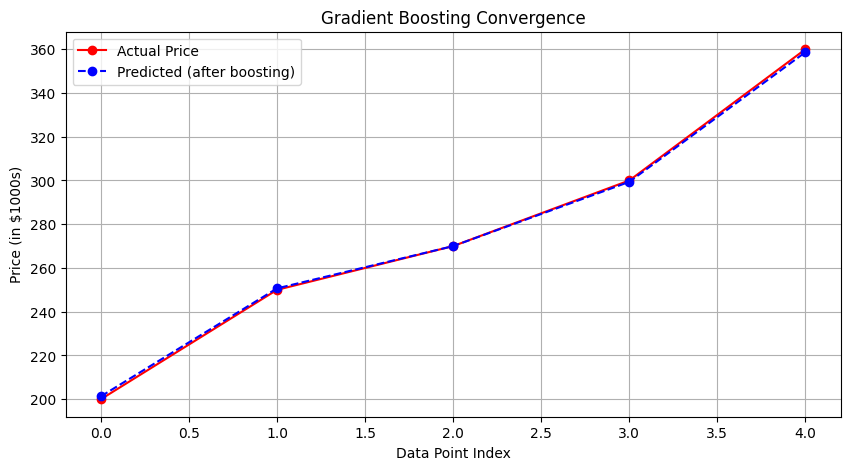

In [ ]:
# --------------------------
# 5. VISUALIZATION
# --------------------------
plt.figure(figsize=(10, 5))
plt.plot(y, 'ro-', label='Actual Price')
plt.plot(pred, 'bo--', label='Predicted (after boosting)')
plt.title("Gradient Boosting Convergence")
plt.xlabel("Data Point Index")
plt.ylabel("Price (in $1000s)")
plt.legend()
plt.grid(True)
plt.show()